# Loan Risk Analyzer  
## Exploratory Data Analysis & Rule-Based Risk Validation

### Objective

The objective of this notebook is to explore historical loan data and validate a rule-based credit risk classification system by analyzing borrower characteristics and observed default behavior.  
The focus of this analysis is on **risk segmentation and rule validation**, rather than predictive modeling.

## 1. Dataset Overview

The dataset consists of historical loan records containing borrower demographics, financial attributes, credit-related indicators, and loan outcomes.

The target variable `Default` indicates whether a borrower defaulted on the loan.

### Key Characteristics

- Each row represents an individual loan application.
- The dataset includes both numerical and categorical features related to creditworthiness.
- No missing values or duplicate records were observed, making the dataset suitable for exploratory analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('../data/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [5]:
df["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

### Key Characteristics

- Each row represents an individual loan application.
- The dataset includes both numerical and categorical features related to creditworthiness.
- No missing values or duplicate records were observed, making the dataset suitable for exploratory analysis.

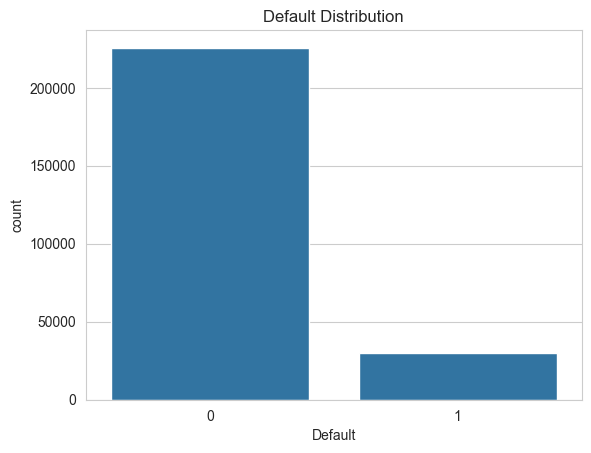

In [6]:
sns.countplot(x="Default", data=df)
plt.title("Default Distribution")
plt.show()

### Observations

- The dataset shows class imbalance, with non-defaulted loans significantly outnumbering defaulted loans.
- This reflects real-world credit portfolios, where default events are relatively infrequent.
- As a result, accuracy alone is not an appropriate evaluation metric for credit risk analysis.

## 3. Feature Distributions (Contextual Analysis)

This section provides a high-level view of key financial indicators to understand their overall spread across the borrower population.  
These distributions are used strictly for **contextual understanding**, not decision-making.

### Credit Score Distribution

Credit scores are distributed across a wide range, enabling meaningful segmentation of borrowers into different credit risk categories.

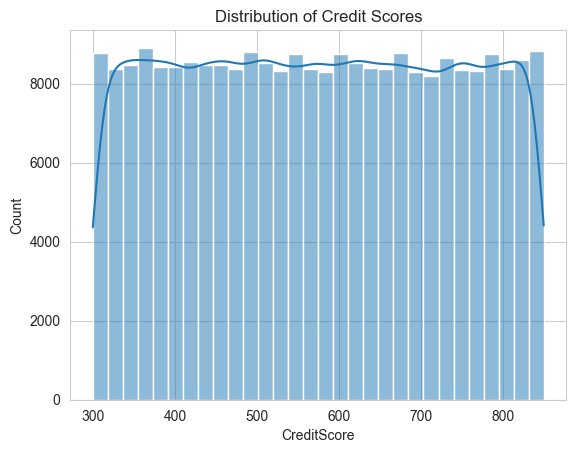

In [7]:
sns.histplot(df["CreditScore"], bins=30, kde=True)
plt.title("Distribution of Credit Scores")
plt.show()

### Debt-to-Income (DTI) Ratio Distribution

The DTI ratio distribution indicates that while most borrowers fall within moderate ranges, a non-trivial portion exhibit high repayment burden, which may contribute to default risk.

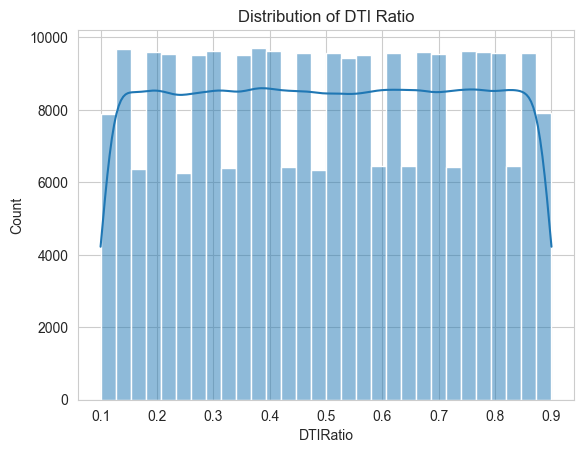

In [8]:
sns.histplot(df["DTIRatio"], bins=30, kde=True)
plt.title("Distribution of DTI Ratio")
plt.show()

## 4. Preliminary Distribution Comparison (Boxplots)

Boxplots are used for an initial visual comparison of borrower characteristics between defaulted and non-defaulted loans.  
This analysis is exploratory in nature and helps identify directional differences between groups.

### Credit Score vs Default

Defaulted borrowers generally exhibit lower median credit scores compared to non-defaulted borrowers.  
However, significant overlap between the two groups indicates that credit score alone is insufficient for precise risk discrimination.

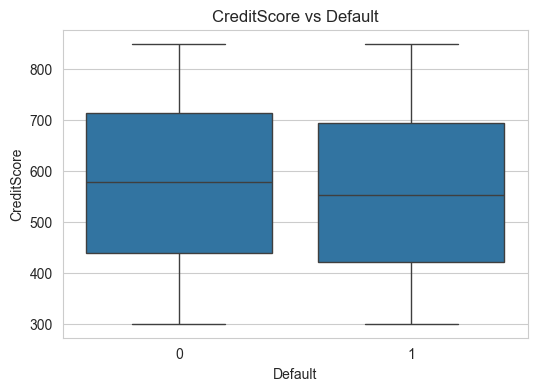

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Default", y="CreditScore", data=df)
plt.title("CreditScore vs Default")
plt.show()

### DTI Ratio vs Default

Defaulted loans show slightly higher median DTI ratios, suggesting increased financial stress.  
The wide spread highlights the non-linear relationship between repayment burden and default risk.

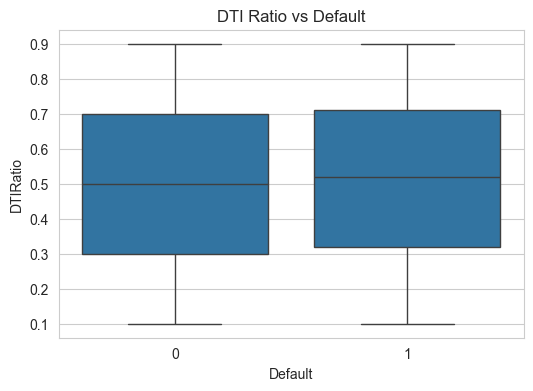

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Default", y="DTIRatio", data=df)
plt.title("DTI Ratio vs Default")
plt.show()

### Loan Amount vs Default

Loan amount shows noticeable overlap between defaulted and non-defaulted borrowers, indicating that loan size must be evaluated in conjunction with other financial factors rather than in isolation.

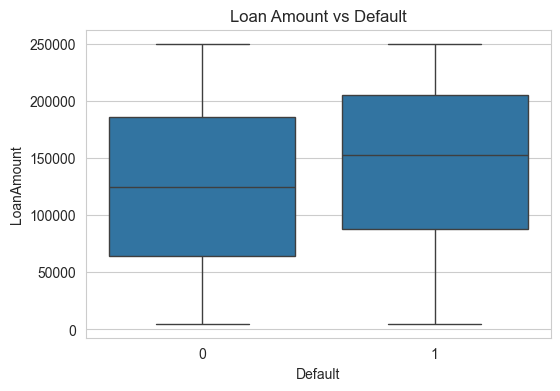

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Default", y="LoanAmount", data=df)
plt.title("Loan Amount vs Default")
plt.show()

### Key Takeaway

While boxplots highlight distributional differences, they do not quantify default risk.  
Therefore, subsequent analysis focuses on **default rate–based validation of rule-driven risk segments**, which is more aligned with real-world credit decision frameworks.

## 5. Rule-Based Risk Engine

A rule-based credit risk classification engine is designed to categorize borrowers into LOW, MEDIUM, and HIGH risk groups using business-driven thresholds.

### Rule Inputs

The rule engine considers the following borrower attributes:

- EMI / DTI Ratio  
- Credit Score  
- Employment Stability  
- Age  
- Loan Tenure  

Each rule contributes risk points, which are aggregated to determine the final risk category.

### Feature Mapping for Rule Engine

To align dataset variables with the rule-based classification logic, selected columns are mapped to business-oriented feature names used by the rule engine.

- `DTIRatio` is mapped to `emi_ratio`
- `LoanTerm` is mapped to `tenure_months`

This ensures clarity between raw dataset variables and business-driven rule inputs.

In [12]:
df["emi_ratio"] = df["DTIRatio"]
df["tenure_months"] = df["LoanTerm"]

In [13]:
def risk_classification(emi_ratio, age, tenure_months, credit_score, months_employed):
    risk_points = 0

    if emi_ratio <= 0.25:
        risk_points += 0
    elif emi_ratio <= 0.45:
        risk_points += 1
    else:
        risk_points += 2

    if credit_score < 550:
        risk_points += 2
    elif credit_score < 650:
        risk_points += 1

    if months_employed < 6:
        risk_points += 2
    elif months_employed < 12:
        risk_points += 1

    if age < 23 or age > 60:
        risk_points += 1

    if tenure_months > 60:
        risk_points += 1

    if risk_points <= 1:
        return "LOW RISK"
    elif risk_points == 2:
        return "MEDIUM RISK"
    else:
        return "HIGH RISK"

### Rule Inputs

The rule engine considers the following borrower attributes:

- EMI / DTI Ratio  
- Credit Score  
- Employment Stability  
- Age  
- Loan Tenure  

Each rule contributes risk points, which are aggregated to determine the final risk category.

In [14]:
df["rule_risk"] = df.apply(
    lambda x: risk_classification(
        x["emi_ratio"],
        x["Age"],
        x["tenure_months"],
        x["CreditScore"],
        x["MonthsEmployed"]
    ),
    axis=1
)

df["rule_risk"].value_counts()

rule_risk
HIGH RISK      151224
MEDIUM RISK     66290
LOW RISK        37833
Name: count, dtype: int64

## 6. Applying the Rule Engine to Historical Data

The rule-based classification logic is applied to all borrowers in the dataset to assign a risk label to each loan application.

This step simulates how the rule engine would behave in a real-world credit screening scenario.

### Credit Score Bands

Default rates increase as credit score decreases, validating the use of credit score thresholds in the rule engine.

In [15]:
df["credit_band"] = pd.cut(
    df["CreditScore"],
    bins=[300, 550, 650, 750, 850],
    labels=["Very Low", "Low", "Medium", "High"]
)

df.groupby("credit_band")["Default"].mean()

credit_band
Very Low    0.125703
Low         0.115022
Medium      0.108108
High        0.100687
Name: Default, dtype: float64

### Credit Score Bands

Default rates increase as credit score decreases, validating the use of credit score thresholds in the rule engine.

In [16]:
df["emi_band"] = pd.cut(
    df["emi_ratio"],
    bins=[0, 0.25, 0.45, 1.0],
    labels=["Low", "Medium", "High"]
)

df.groupby("emi_band")["Default"].mean()

emi_band
Low       0.105804
Medium    0.112412
High      0.121389
Name: Default, dtype: float64

### Employment Stability

Shorter employment duration is associated with higher default probability, confirming employment stability as a meaningful risk driver.

In [17]:
df["employment_band"] = pd.cut(
    df["MonthsEmployed"],
    bins=[0, 6, 12, 100],
    labels=["<6 months", "6–12 months", ">12 months"]
)

df.groupby("employment_band")["Default"].mean()

employment_band
<6 months      0.173567
6–12 months    0.162508
>12 months     0.117457
Name: Default, dtype: float64

### Employment Stability

Shorter employment duration is associated with higher default probability, confirming employment stability as a meaningful risk driver.

### Credit Score × DTI Interaction

Borrowers with both low credit scores and high DTI ratios exhibit significantly higher default rates, demonstrating the compounding nature of credit risk.

In [18]:
pd.crosstab(
    df["credit_band"],
    df["emi_band"],
    values=df["Default"],
    aggfunc="mean"
)

emi_band,Low,Medium,High
credit_band,,,
Very Low,0.114315,0.122870,0.130904
Low,0.110403,0.113753,0.117202
Medium,0.097631,0.099938,0.115483
High,0.087173,0.096602,0.107192


## 9. Rule-Based Risk Segmentation Performance

The table below summarizes borrower distribution and observed default rates across rule-based risk categories.

In [19]:
rule_performance = (
    df.groupby("rule_risk")["Default"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "default_rate"})
)

rule_performance

,count,default_rate
rule_risk,,
HIGH RISK,151224,0.125410
LOW RISK,37833,0.094521
MEDIUM RISK,66290,0.107286


### Observations

- Default rates increase monotonically from LOW to HIGH risk categories.
- The separation between risk groups is present but relatively narrow, indicating that rule-based logic provides coarse risk segmentation.
- Medium-risk borrowers exhibit mixed default behavior, reflecting uncertainty in borderline cases.

## 10. EDA Conclusions & Key Insights

- The rule-based risk classification system captures meaningful risk signals and aligns with historical default behavior.
- Low-risk borrowers demonstrate relatively lower default rates, supporting automated approval decisions.
- High-risk borrowers show elevated default rates, justifying rejection or manual review.
- Medium-risk borrowers represent an uncertain segment where rule-based decisions alone are insufficient.

### Final Conclusion

The analysis confirms that the rule-based engine functions effectively as a **first-layer credit screening mechanism**.  
The observed ambiguity in medium-risk cases motivates the use of advanced data-driven models for further risk refinement.